**Install sodapy library. Which is a python client fo the Socrata Open Data API**

In [15]:
!pip install sodapy pandas

Import Socrata which is an Open Data API that allows you to programmatically access a wealth of open data resources from governments, non-profits, and NGOs around the world.

https://dev.socrata.com/

In [16]:
from sodapy import Socrata
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Set a random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)

# App token is optional for public datasets
client = Socrata("www.dallasopendata.com", app_token=None)

# Fetch 10,000 records between 2014–2024 with only needed fields
results = client.get(
    "qv6i-rri7",  # Dataset ID
    select="servyr, offincident, nibrs_crime_category, premise, division",
    where="servyr between 2014 and 2024",
    limit=10000
)

# Convert to DataFrame
df = pd.DataFrame.from_records(results)

# Convert year to integer (comes in as string)
df["servyr"] = df["servyr"].astype(int)

# Show data info
print(df.head())
print(df["servyr"].value_counts().sort_index())

   servyr                                        offincident  \
0    2020                        ASSAULT -BODILY INJURY ONLY   
1    2015                        FOUND PROPERTY (NO OFFENSE)   
2    2017                    ABANDONED PROPERTY (NO OFFENSE)   
3    2023                                POSS MARIJUANA <2OZ   
4    2020  UNLAWFUL DISCLOSURE OR PROMOTION OF INTIMATE V...   

        nibrs_crime_category                                premise  \
0           ASSAULT OFFENSES     Single Family Residence - Occupied   
1                        NaN     Single Family Residence - Occupied   
2              MISCELLANEOUS             Highway, Street, Alley ETC   
3  DRUG/ NARCOTIC VIOLATIONS                     Parking (Business)   
4         ALL OTHER OFFENSES  Restaurant/Food Service/TABC Location   

        division  
0      SOUTHWEST  
1      SOUTHEAST  
2      SOUTHWEST  
3  NORTH CENTRAL  
4      SOUTHEAST  
servyr
2014     361
2015     507
2016     251
2017     230
2018     808
20

In [17]:
df.head()


,servyr,offincident,nibrs_crime_category,premise,division
0,2020,ASSAULT -BODILY INJURY ONLY,ASSAULT OFFENSES,Single Family Residence - Occupied,SOUTHWEST
1,2015,FOUND PROPERTY (NO OFFENSE),NaN,Single Family Residence - Occupied,SOUTHEAST
2,2017,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
3,2023,POSS MARIJUANA <2OZ,DRUG/ NARCOTIC VIOLATIONS,Parking (Business),NORTH CENTRAL
4,2020,UNLAWFUL DISCLOSURE OR PROMOTION OF INTIMATE V...,ALL OTHER OFFENSES,Restaurant/Food Service/TABC Location,SOUTHEAST


In [18]:
dallas = df

In [19]:
dallas.to_csv('dallas.csv', index=False)


In [20]:
#from google.colab import files
#files.download("dallas.csv")


In [21]:
dallas2 = dallas
dallas2.dropna()
print(len(dallas2))

10000


In [22]:
dallas2.value_counts()

servyr  offincident                                   nibrs_crime_category       premise                      division     
2023    POSS MARIJUANA <2OZ                           DRUG/ NARCOTIC VIOLATIONS  Highway, Street, Alley ETC   SOUTHWEST        201
        ABANDONED PROPERTY (NO OFFENSE)               MISCELLANEOUS              Highway, Street, Alley ETC   SOUTHWEST        168
2022    ABANDONED PROPERTY (NO OFFENSE)               MISCELLANEOUS              Highway, Street, Alley ETC   SOUTHWEST        141
        POSS MARIJUANA <2OZ                           DRUG/ NARCOTIC VIOLATIONS  Highway, Street, Alley ETC   SOUTHWEST        131
2019    ABANDONED PROPERTY (NO OFFENSE)               MISCELLANEOUS              Highway, Street, Alley ETC   SOUTH CENTRAL     81
                                                                                                                              ... 
        SEIZED PROPERTY (NO OFFENSE)                  MISCELLANEOUS              Parking (Business)           SOUTH CENTRAL      1
                                                                                                              NORTHWEST          1
                                                                                                              NORTH CENTRAL      1
2017    ABANDONED PROPERTY (NO OFFENSE)               MISCELLANEOUS              Highway, Street, Alley ETC   NORTHEAST          1
2024    UNAUTHORIZED USE OF MOTOR VEH - TRUCK OR BUS  MOTOR VEHICLE THEFT        Outdoor Area Public/Private  SOUTHEAST          1
Name: count, Length: 4507, dtype: int64

In [23]:
dallas2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   servyr                10000 non-null  int64 
 1   offincident           10000 non-null  object
 2   nibrs_crime_category  8805 non-null   object
 3   premise               9983 non-null   object
 4   division              9993 non-null   object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [24]:
dallas2.isnull().sum()

,0
servyr,0
offincident,0
nibrs_crime_category,1195
premise,17
division,7


In [25]:
dallas2[['nibrs_crime_category', 'servyr']].value_counts()

nibrs_crime_category               servyr
MISCELLANEOUS                      2023      717
DRUG/ NARCOTIC VIOLATIONS          2023      605
MISCELLANEOUS                      2020      595
                                   2022      550
                                   2019      543
                                            ... 
ROBBERY                            2021        1
TRAFFIC VIOLATION - NON HAZARDOUS  2021        1
TRAFFIC VIOLATION - HAZARDOUS      2024        1
TRESPASS OF REAL PROPERTY          2023        1
                                   2021        1
Name: count, Length: 161, dtype: int64

In [26]:
# Group by year and sum null values for each column
null_counts_by_year = dallas2.groupby('servyr').apply(lambda x: x.isnull().sum())


null_counts_by_year

/tmp/ipython-input-1547982725.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_counts_by_year = dallas2.groupby('servyr').apply(lambda x: x.isnull().sum())


,servyr,offincident,nibrs_crime_category,premise,division
servyr,,,,,
2014,0,0,361,4,0
2015,0,0,506,1,0
2016,0,0,251,0,0
2017,0,0,0,0,0
2018,0,0,0,2,0
2019,0,0,0,2,0
2020,0,0,0,0,1
2021,0,0,0,3,1
2022,0,0,0,0,1


In [27]:
dallas2 = pd.read_csv('dallas (3).csv')
dallas2.head()

/tmp/ipython-input-2490549592.py:1: DtypeWarning: Columns (1,2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  dallas2 = pd.read_csv('dallas (3).csv')


,servyr,offincident,nibrs_crime_category,premise,division
0,2015.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
1,2014.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Apartment Parking Lot,NORTHEAST
2,2016.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
3,2014.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Parking Lot (All Others),SOUTH CENTRAL
4,2016.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST


In [28]:
dallas2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   servyr                9790 non-null   float64
 1   offincident           9790 non-null   object 
 2   nibrs_crime_category  9790 non-null   object 
 3   premise               9790 non-null   object 
 4   division              9790 non-null   object 
dtypes: float64(1), object(4)
memory usage: 40.0+ MB


**Rename Columns for Clarity**

In [29]:
dallas2.rename(columns={'servyr': 'year',
                   'offincident': 'crime',
                   'nibrs_crime_category': 'crime_category',
                   'premise': 'location',
                   'division': 'division'}, inplace=True)
dallas2.head()

,year,crime,crime_category,location,division
0,2015.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
1,2014.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Apartment Parking Lot,NORTHEAST
2,2016.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
3,2014.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Parking Lot (All Others),SOUTH CENTRAL
4,2016.0,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score



In [31]:
dallas2.dropna(inplace=True)

In [32]:
dallas2['year'] = dallas2['year'].astype(int)

In [33]:
dallas_sample = dallas2

In [34]:
train_data = dallas_sample[dallas_sample['year'] < 2023]
test_data = dallas_sample[dallas_sample['year'] >= 2024]
train_data.head()

,year,crime,crime_category,location,division
0,2015,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
1,2014,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Apartment Parking Lot,NORTHEAST
2,2016,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST
3,2014,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,Parking Lot (All Others),SOUTH CENTRAL
4,2016,ABANDONED PROPERTY (NO OFFENSE),MISCELLANEOUS,"Highway, Street, Alley ETC",SOUTHWEST


In [35]:
dallas_sample['location'].value_counts()

,count
location,
"Highway, Street, Alley ETC",1733
Single Family Residence - Occupied,1094
Apartment Parking Lot,866
Apartment Complex/Building,780
Parking (Business),658
...,...
Trails,3
Dock/Wharf/Freight/Modal Terminal,3
Rental Storage Facility,3


One Hot Encoding to transform categorial to numerical

In [36]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['crime', 'crime_category'])
    ])

In [37]:
# Model Definitions
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced')
}


Select Inputs (Crime/ Crime_category)

In [38]:
# Training Data
X_train = dallas2[dallas2['year'] < 2024][['crime', 'crime_category']]
y_train = dallas2[dallas2['year'] < 2024]['location']

Pipeline: Preprocess + logistic regression

#Cross Validation

In [39]:
# Cross-validation
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])
    print(f"\n{name} - 3-Fold Cross-Validation")
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy')
    print("Fold Scores:", scores)
    print("Mean Accuracy:", round(scores.mean(), 4))


Logistic Regression - 3-Fold Cross-Validation


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Fold Scores: [0.01605434 0.00741198 0.0302656 ]
Mean Accuracy: 0.0179

K-Nearest Neighbors - 3-Fold Cross-Validation


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Fold Scores: [0.05588144 0.04910439 0.04910439]
Mean Accuracy: 0.0514

Random Forest - 3-Fold Cross-Validation


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Fold Scores: [0.0994134  0.01358863 0.14051884]
Mean Accuracy: 0.0845


In [40]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# Holdout Test Set
X_test = dallas2[dallas2['year'] == 2024][['crime', 'crime_category']]
y_test = dallas2[dallas2['year'] == 2024]['location']
y_test_binarized = label_binarize(y_test, classes=y_train.unique())


In [41]:
# Evaluate Each Model
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    print(f"\n{name} - Holdout Evaluation (2024)")
    print(classification_report(y_test, y_pred))

    if len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted', labels=pipe.named_steps['clf'].classes_)
        print(f"AUC Score: {round(auc, 4)}")
    else:
        print("AUC not computed: only one class present in holdout.")


Logistic Regression - Holdout Evaluation (2024)
                                          precision    recall  f1-score   support

           Abandoned/Condemned Structure       0.00      0.00      0.00         0
              Apartment Complex/Building       0.00      0.00      0.00         5
                   Apartment Parking Lot       0.50      0.14      0.22         7
                     Apartment Residence       1.00      0.20      0.33         5
      Arena/Stadium/Fairgrounds/Coliseum       0.00      0.00      0.00         0
                Auto Dealership New/Used       0.00      0.00      0.00         0
                         Business Office       0.00      0.00      0.00         3
          Church/Synagogue/Temple/Mosque       0.00      0.00      0.00         1
         City Park/Rec/Tennis/Golf/Trail       0.00      0.00      0.00         0
     Commercial Property Occupied/Vacant       0.00      0.00      0.00         3
           Condominium/Townhome Building       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


K-Nearest Neighbors - Holdout Evaluation (2024)
                                       precision    recall  f1-score   support

           Apartment Complex/Building       0.00      0.00      0.00         5
                Apartment Parking Lot       0.15      0.29      0.20         7
                  Apartment Residence       0.00      0.00      0.00         5
                      Business Office       0.00      0.00      0.00         3
       Church/Synagogue/Temple/Mosque       0.00      0.00      0.00         1
  Commercial Property Occupied/Vacant       0.14      0.33      0.20         3
                    Construction Site       0.00      0.00      0.00         1
                    Convenience Store       0.00      0.00      0.00         0
           Highway, Street, Alley ETC       0.27      0.58      0.37        12
                      Hotel/Motel/ETC       0.00      0.00      0.00         3
                                Other       0.33      0.14      0.20         7
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


Random Forest - Holdout Evaluation (2024)
                                          precision    recall  f1-score   support

           Abandoned/Condemned Structure       0.00      0.00      0.00         0
              Apartment Complex/Building       0.00      0.00      0.00         5
                   Apartment Parking Lot       0.50      0.14      0.22         7
                     Apartment Residence       1.00      0.20      0.33         5
      Arena/Stadium/Fairgrounds/Coliseum       0.00      0.00      0.00         0
                Auto Dealership New/Used       0.00      0.00      0.00         0
                         Business Office       0.00      0.00      0.00         3
          Church/Synagogue/Temple/Mosque       0.00      0.00      0.00         1
         City Park/Rec/Tennis/Golf/Trail       0.00      0.00      0.00         0
     Commercial Property Occupied/Vacant       0.00      0.00      0.00         3
           Condominium/Townhome Building       0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [42]:
from sklearn.metrics import accuracy_score

# Accuracy for each model
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.0667
K-Nearest Neighbors Accuracy: 0.1867
Random Forest Accuracy: 0.0400


Visualizations

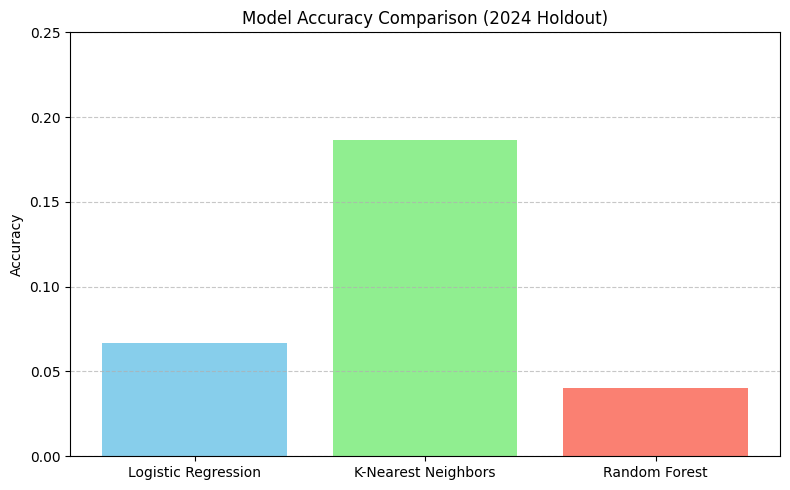

In [43]:
import matplotlib.pyplot as plt

accuracy_scores = {
    'Logistic Regression': 0.0667,
    'K-Nearest Neighbors': 0.1867,
    'Random Forest': 0.0400
}

plt.figure(figsize=(8, 5))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Accuracy Comparison (2024 Holdout)')
plt.ylabel('Accuracy')
plt.ylim(0, 0.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This chart highlights that KNN achieved the highest accuracy, followed by Logistic Regression. Random Forest performed the worst in this context.

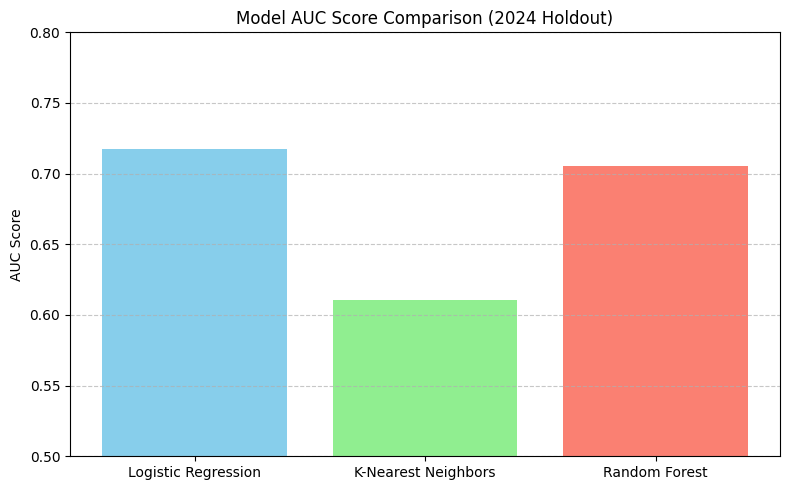

In [44]:
auc_scores = {
    'Logistic Regression': 0.7175,
    'K-Nearest Neighbors': 0.6107,
    'Random Forest': 0.7054
}

plt.figure(figsize=(8, 5))
plt.bar(auc_scores.keys(), auc_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model AUC Score Comparison (2024 Holdout)')
plt.ylabel('AUC Score')
plt.ylim(0.5, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

UC provides a view into the ranking performance. Logistic Regression outperformed the others, suggesting it better ranks class probabilities even though accuracy was lower.

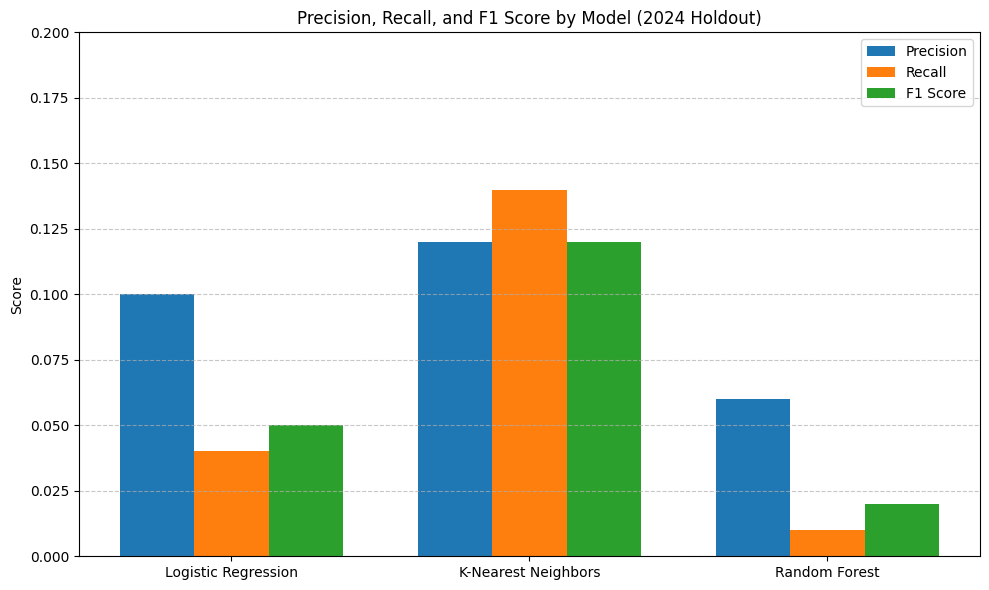

In [45]:


models = ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest']
precision = [0.10, 0.12, 0.06]
recall = [0.04, 0.14, 0.01]
f1 = [0.05, 0.12, 0.02]

x = range(len(models))
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x, precision, width=bar_width, label='Precision')
plt.bar([i + bar_width for i in x], recall, width=bar_width, label='Recall')
plt.bar([i + bar_width*2 for i in x], f1, width=bar_width, label='F1 Score')

plt.xticks([i + bar_width for i in x], models)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score by Model (2024 Holdout)')
plt.ylim(0, 0.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Top 5 for Logistic Regression

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score

# 1. Keep only top 5 locations
top_5 = dallas2['location'].value_counts().nlargest(5).index
dallas_top5 = dallas2[dallas2['location'].isin(top_5)]

# 2. Split into train and test sets
train_top5 = dallas_top5[dallas_top5['year'] < 2024]
test_top5 = dallas_top5[dallas_top5['year'] == 2024]

X_train = train_top5[['crime', 'crime_category']]
y_train = train_top5['location']
X_test = test_top5[['crime', 'crime_category']]
y_test = test_top5['location']



model = Pipeline([
    ('prep', preprocess),
    ('logreg', LogisticRegression(max_iter=500, class_weight='balanced'))
])

# 4. Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))

# 5. Train and evaluate on 2024 holdout
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nTop 5 Location Classification Report:")
print(classification_report(y_test, y_pred))
print("Top 5 Accuracy:", round(accuracy_score(y_test, y_pred), 4))


Cross-Validation Scores: [0.22202591 0.12367491 0.23571008]
Mean CV Accuracy: 0.1938

Top 5 Location Classification Report:
                                    precision    recall  f1-score   support

        Apartment Complex/Building       0.25      0.40      0.31         5
             Apartment Parking Lot       0.47      1.00      0.64         7
        Highway, Street, Alley ETC       1.00      0.33      0.50        12
                Parking (Business)       0.33      0.22      0.27         9
Single Family Residence - Occupied       0.20      0.20      0.20         5

                          accuracy                           0.42        38
                         macro avg       0.45      0.43      0.38        38
                      weighted avg       0.54      0.42      0.41        38

Top 5 Accuracy: 0.4211


##Top 5 for KNN

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score



model = Pipeline([
    ('prep', preprocess),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# 4. Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))

# 5. Train and evaluate on 2024 holdout
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nTop 5 Location Classification Report:")
print(classification_report(y_test, y_pred))
print("Top 5 Accuracy:", round(accuracy_score(y_test, y_pred), 4))


Cross-Validation Scores: [0.3598351  0.17020024 0.1543901 ]
Mean CV Accuracy: 0.2281

Top 5 Location Classification Report:
                                    precision    recall  f1-score   support

        Apartment Complex/Building       0.20      0.60      0.30         5
             Apartment Parking Lot       0.29      0.29      0.29         7
        Highway, Street, Alley ETC       1.00      0.33      0.50        12
                Parking (Business)       0.00      0.00      0.00         9
Single Family Residence - Occupied       0.33      0.40      0.36         5

                          accuracy                           0.29        38
                         macro avg       0.36      0.32      0.29        38
                      weighted avg       0.44      0.29      0.30        38

Top 5 Accuracy: 0.2895


##Top 5 for Random Forest

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score



model = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# 4. Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))

# 5. Train and evaluate on 2024 holdout
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nTop 5 Location Classification Report:")
print(classification_report(y_test, y_pred))
print("Top 5 Accuracy:", round(accuracy_score(y_test, y_pred), 4))


Cross-Validation Scores: [0.24028269 0.15783274 0.25103123]
Mean CV Accuracy: 0.2164

Top 5 Location Classification Report:
                                    precision    recall  f1-score   support

        Apartment Complex/Building       0.25      0.40      0.31         5
             Apartment Parking Lot       0.47      1.00      0.64         7
        Highway, Street, Alley ETC       1.00      0.33      0.50        12
                Parking (Business)       0.33      0.22      0.27         9
Single Family Residence - Occupied       0.20      0.20      0.20         5

                          accuracy                           0.42        38
                         macro avg       0.45      0.43      0.38        38
                      weighted avg       0.54      0.42      0.41        38

Top 5 Accuracy: 0.4211


##Top 5 Metrics

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Filter for Top 5
top_5 = dallas2['location'].value_counts().nlargest(5).index
dallas_top5 = dallas2[dallas2['location'].isin(top_5)]
train_top5 = dallas_top5[dallas_top5['year'] < 2024]
test_top5 = dallas_top5[dallas_top5['year'] == 2024]

X_train = train_top5[['crime', 'crime_category']]
y_train = train_top5['location']
X_test = test_top5[['crime', 'crime_category']]
y_test = test_top5['location']

In [50]:
# Ensure model dictionary is defined
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

In [51]:
# Run for each model
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n{name} - Top 5 Locations Holdout Evaluation (2024)")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression - Top 5 Locations Holdout Evaluation (2024)
                                    precision    recall  f1-score   support

        Apartment Complex/Building       0.25      0.40      0.31         5
             Apartment Parking Lot       0.47      1.00      0.64         7
        Highway, Street, Alley ETC       1.00      0.33      0.50        12
                Parking (Business)       0.33      0.22      0.27         9
Single Family Residence - Occupied       0.20      0.20      0.20         5

                          accuracy                           0.42        38
                         macro avg       0.45      0.43      0.38        38
                      weighted avg       0.54      0.42      0.41        38


K-Nearest Neighbors - Top 5 Locations Holdout Evaluation (2024)
                                    precision    recall  f1-score   support

        Apartment Complex/Building       0.20      0.60      0.30         5
             Apartment Parking

In [52]:
    # AUC Score: only compute if more than one class is in y_test
    if hasattr(pipe.named_steps['clf'], "predict_proba"):
        try:
            y_proba = pipe.predict_proba(X_test)
            auc = roc_auc_score(
                y_test, y_proba,
                multi_class='ovr',
                average='weighted',
                labels=pipe.named_steps['clf'].classes_
            )
            print(f"AUC Score: {round(auc, 4)}")
        except ValueError as e:
            print("AUC not computed:", str(e))
    else:
        print("AUC not available: classifier has no predict_proba method.")


AUC Score: 0.8151


In [53]:
print("Top 5 Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Top 5 Accuracy: 0.4211


In [54]:
from sklearn.metrics import accuracy_score

# Accuracy for each model
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.4211
K-Nearest Neighbors Accuracy: 0.2895
Random Forest Accuracy: 0.4211


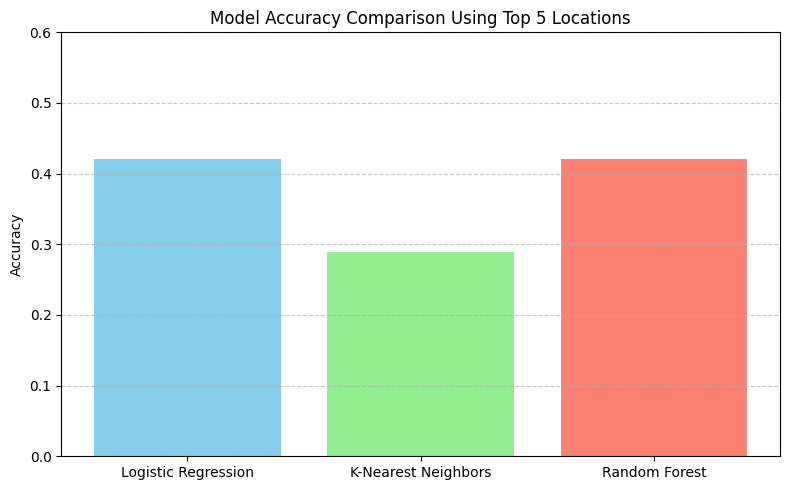

In [55]:
accuracy_scores = {
    'Logistic Regression': 0.4211,
    'K-Nearest Neighbors': 0.2895,
    'Random Forest': 0.4211
}

plt.figure(figsize=(8, 5))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Accuracy Comparison Using Top 5 Locations')
plt.ylabel('Accuracy')
plt.ylim(0, 0.60)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

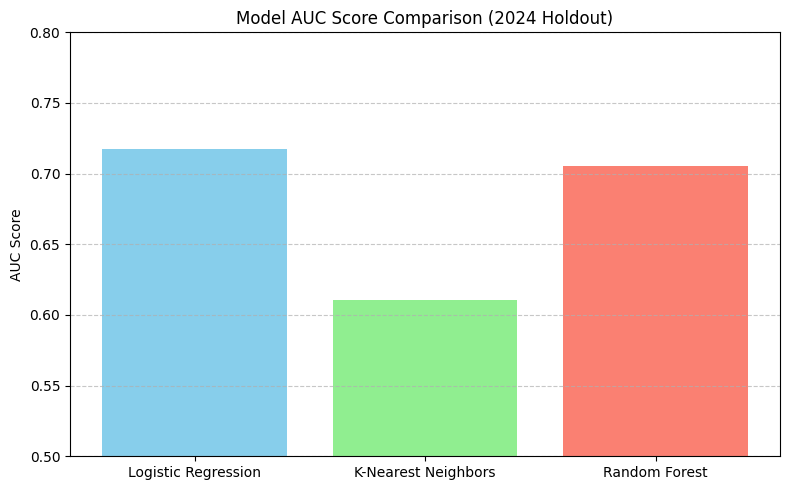

In [56]:
auc_scores = {
    'Logistic Regression': 0.7175,
    'K-Nearest Neighbors': 0.6107,
    'Random Forest': 0.7054
}

plt.figure(figsize=(8, 5))
plt.bar(auc_scores.keys(), auc_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model AUC Score Comparison (2024 Holdout)')
plt.ylabel('AUC Score')
plt.ylim(0.5, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

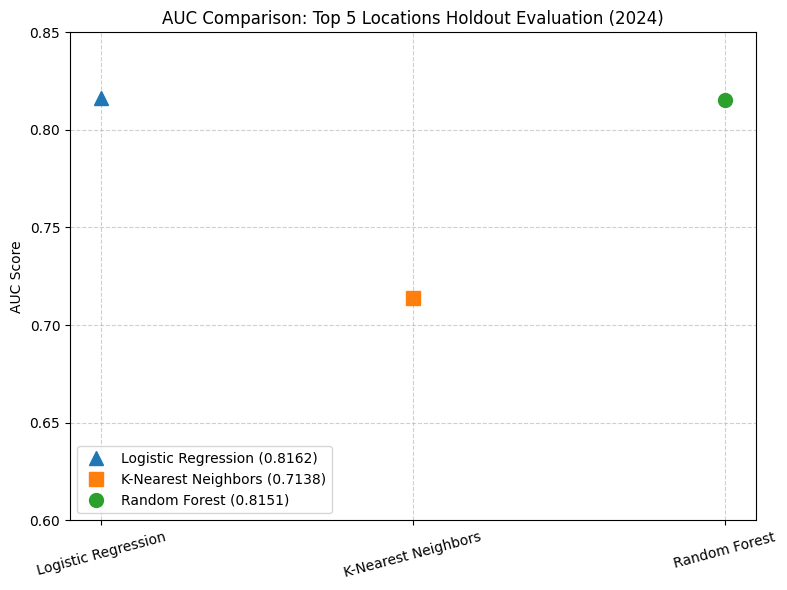

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# AUC scores for the models
models = ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest']
auc_scores = [0.8162, 0.7138, 0.8151]

# Marker styles: triangle (^), square (s), circle (o)
markers = ['^', 's', 'o']

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each model's AUC score with corresponding marker
for i, (model, auc, marker) in enumerate(zip(models, auc_scores, markers)):
    plt.plot(i, auc, marker=marker, markersize=10, label=f'{model} ({auc:.4f})', linestyle='None')

# Customize chart appearance
plt.xticks(ticks=np.arange(len(models)), labels=models, rotation=15)
plt.ylim(0.6, 0.85)
plt.ylabel('AUC Score')
plt.title('AUC Comparison: Top 5 Locations Holdout Evaluation (2024)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


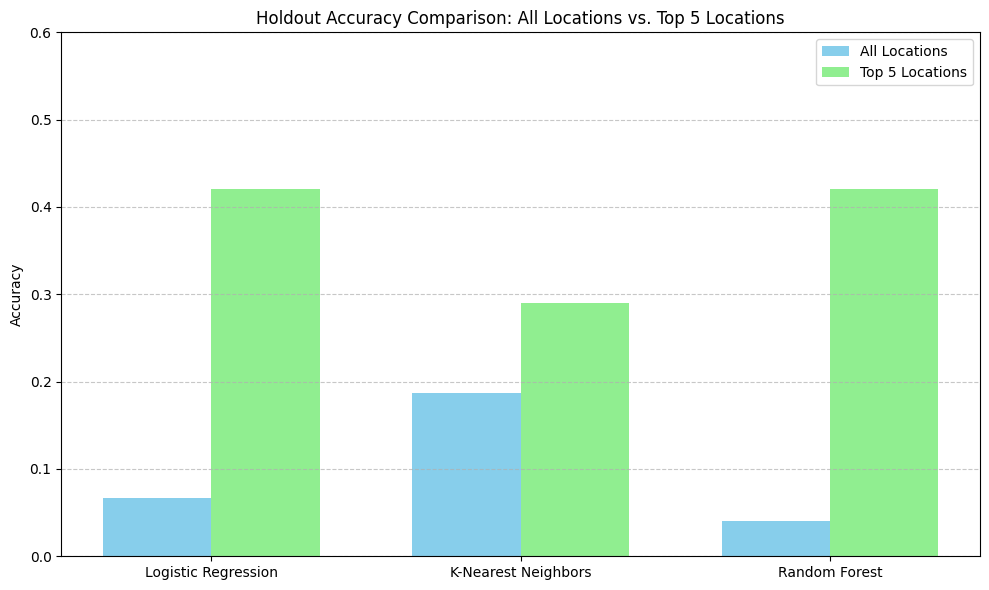

In [58]:
# prompt: So I used the all locations and top 5 locations, can you make a barchart comparing the holdout accuracy for both the all locations and top 5

import matplotlib.pyplot as plt

# Accuracy scores for all locations and top 5 locations
accuracy_scores = {
    'All Locations': {
        'Logistic Regression': 0.0667,
        'K-Nearest Neighbors': 0.1867,
        'Random Forest': 0.0400
    },
    'Top 5 Locations': {
        'Logistic Regression': 0.4211,
        'K-Nearest Neighbors': 0.2895,
        'Random Forest': 0.4211
    }
}

# Create the bar chart
models = list(accuracy_scores['All Locations'].keys())
all_locations_accuracy = list(accuracy_scores['All Locations'].values())
top_5_accuracy = list(accuracy_scores['Top 5 Locations'].values())

x = range(len(models))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x, all_locations_accuracy, width=bar_width, label='All Locations', color='skyblue')
plt.bar([i + bar_width for i in x], top_5_accuracy, width=bar_width, label='Top 5 Locations', color='lightgreen')

plt.xticks([i + bar_width / 2 for i in x], models)
plt.ylabel('Accuracy')
plt.title('Holdout Accuracy Comparison: All Locations vs. Top 5 Locations')
plt.ylim(0, 0.6) # Adjust ylim as needed
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
